In [ ]:
#### Q-1)Below questions are based on this data(ncr_ride_bookings):-
1)Convert Date and Time to datetime

2)Combine Date and Time into a single datetime column

3)Extract temporal features

4)Create binary flags from cancellation/incomplete columns

5)Create a flag for missing ratings and booking values

6)Define Target for Customer Cancellation

7)Cancellation Rate by Vehicle Type

8)Cancellation Rate by Hour

9)Cancellation Rate by Day of Week

10)Driver Rating vs Cancellation

11)Top 10 Pickup Locations by Count

12)Trend of Cancellations Over Time (Daily)

In [580]:
import numpy as np
import pandas as pd


In [595]:
rides = pd.read_csv("ncr_ride_bookings.csv")
rides.sample(5)

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
94934,2024-09-22,20:41:30,"""CNR7391832""",Completed,"""CID9384959""",Auto,Sarojini Nagar,Gurgaon Railway Station,3.4,16.8,...,NaN,NaN,NaN,NaN,NaN,359.0,36.84,4.9,3.6,UPI
140731,2024-09-25,15:55:25,"""CNR3737005""",Completed,"""CID8908256""",Go Sedan,GTB Nagar,Mehrauli,10.9,17.4,...,NaN,NaN,NaN,NaN,NaN,70.0,28.80,4.7,4.4,UPI
94623,2024-08-04,18:23:55,"""CNR8190533""",Completed,"""CID4788837""",Bike,Shahdara,Peeragarhi,3.9,23.9,...,NaN,NaN,NaN,NaN,NaN,668.0,45.61,4.5,4.5,UPI
29367,2024-01-15,14:58:02,"""CNR8901031""",Completed,"""CID7232762""",Auto,Gurgaon Sector 56,ITO,13.8,31.8,...,NaN,NaN,NaN,NaN,NaN,600.0,46.18,4.2,4.6,Credit Card
82154,2024-02-18,18:54:17,"""CNR3658561""",Completed,"""CID2788639""",Go Sedan,Delhi Gate,Connaught Place,3.8,20.1,...,NaN,NaN,NaN,NaN,NaN,538.0,39.96,4.9,5.0,UPI


#### 1)Convert Date and Time to datetime

In [596]:
rides["Date"] = pd.to_datetime(rides["Date"])

In [597]:
rides["Time"] = pd.to_datetime(rides["Time"], format="%H:%M:%S")


In [598]:
rides["Date"].dtype

dtype('<M8[ns]')

In [599]:
rides["Time"].dtype

dtype('<M8[ns]')

#### 2)Combine Date and Time into a single datetime column

In [600]:

# Convert separately
rides["Date"] = pd.to_datetime(rides["Date"], format="%Y-%m-%d", errors="coerce")
rides["Time"] = pd.to_datetime(rides["Time"], format="%H:%M:%S", errors="coerce").dt.time

# Combine into one DateTime column
rides["DateTime"] = pd.to_datetime(rides["Date"].astype(str) + " " + rides["Time"].astype(str))


In [601]:
rides

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,DateTime
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-03-23 12:29:38
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI,2024-11-29 18:01:39
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card,2024-08-23 08:56:10
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI,2024-10-21 17:17:25
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI,2024-09-16 22:08:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,2024-11-11,19:34:01,"""CNR6500631""",Completed,"""CID4337371""",Go Mini,MG Road,Ghitorni,10.2,44.4,...,NaN,NaN,NaN,NaN,475.0,40.08,3.7,4.1,Uber Wallet,2024-11-11 19:34:01
149996,2024-11-24,15:55:09,"""CNR2468611""",Completed,"""CID2325623""",Go Mini,Golf Course Road,Akshardham,5.1,30.8,...,NaN,NaN,NaN,NaN,1093.0,21.31,4.8,5.0,UPI,2024-11-24 15:55:09
149997,2024-09-18,10:55:15,"""CNR6358306""",Completed,"""CID9925486""",Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,...,NaN,NaN,NaN,NaN,852.0,15.93,3.9,4.4,Cash,2024-09-18 10:55:15
149998,2024-10-05,07:53:34,"""CNR3030099""",Completed,"""CID9415487""",Auto,Ghaziabad,Saidulajab,6.9,39.6,...,NaN,NaN,NaN,NaN,333.0,45.54,4.1,3.7,UPI,2024-10-05 07:53:34


#### 3)Extract temporal features

#### 4)Create binary flags from cancellation/incomplete columns

In [612]:
rides = rides.replace("null", np.nan)

In [613]:
rides["CancelledByCustomer_flag"] = rides["Cancelled Rides by Customer"].fillna(0).astype(int)
rides["CancelledByDriver_flag"]  = rides["Cancelled Rides by Driver"].fillna(0).astype(int)
rides["Incomplete_flag"] = rides["Incomplete Rides"].fillna(0).astype(int)


In [614]:
rides

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Driver Ratings,Customer Rating,Payment Method,DateTime,CancelledByCustomer_flag,CancelledByDriver_flag,Incomplete_flag,CustomerRatings_flag,DriverRatings_flag,BookingVal_flag
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,2024-03-23 12:29:38,0,0,0,0,0,0
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,UPI,2024-11-29 18:01:39,0,0,1,0,0,1
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,4.9,4.9,Debit Card,2024-08-23 08:56:10,0,0,0,1,1,1
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,4.6,5.0,UPI,2024-10-21 17:17:25,0,0,0,1,1,1
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,4.1,4.3,UPI,2024-09-16 22:08:00,0,0,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,2024-11-11,19:34:01,"""CNR6500631""",Completed,"""CID4337371""",Go Mini,MG Road,Ghitorni,10.2,44.4,...,3.7,4.1,Uber Wallet,2024-11-11 19:34:01,0,0,0,1,1,1
149996,2024-11-24,15:55:09,"""CNR2468611""",Completed,"""CID2325623""",Go Mini,Golf Course Road,Akshardham,5.1,30.8,...,4.8,5.0,UPI,2024-11-24 15:55:09,0,0,0,1,1,1
149997,2024-09-18,10:55:15,"""CNR6358306""",Completed,"""CID9925486""",Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,...,3.9,4.4,Cash,2024-09-18 10:55:15,0,0,0,1,1,1
149998,2024-10-05,07:53:34,"""CNR3030099""",Completed,"""CID9415487""",Auto,Ghaziabad,Saidulajab,6.9,39.6,...,4.1,3.7,UPI,2024-10-05 07:53:34,0,0,0,1,1,1


In [619]:

rides["Cancellation_flag"] = np.where(
    (rides["Cancelled Rides by Customer"].notna()) | (rides["Cancelled Rides by Driver"].notna()),
    1, 0
)


In [615]:
#5)Create a flag for missing ratings and booking value
# rides["CustomerRatings_flag"] = rides["Customer Rating"].fillna(0).astype(int)
# rides["DriverRatings_flag"]  = rides["Driver Ratings"].fillna(0).astype(int)
# rides["BookingVal_flag"]  = rides["Booking Value"].fillna(0).astype(int)


In [616]:
rides["CustomerRatings_flag"] = np.where(rides["Customer Rating"].notna(), 1, 0)
rides["DriverRatings_flag"]   = np.where(rides["Driver Ratings"].notna(), 1, 0)
rides["BookingVal_flag"]      = np.where(rides["Booking Value"].notna(), 1, 0)


In [618]:
rides.sample(5)

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Driver Ratings,Customer Rating,Payment Method,DateTime,CancelledByCustomer_flag,CancelledByDriver_flag,Incomplete_flag,CustomerRatings_flag,DriverRatings_flag,BookingVal_flag
144654,2024-02-10,22:20:55,"""CNR7962327""",Completed,"""CID4384546""",eBike,IMT Manesar,Patel Chowk,6.6,17.5,...,4.4,4.6,Cash,2024-02-10 22:20:55,0,0,0,1,1,1
75254,2024-09-27,12:43:14,"""CNR2784230""",Cancelled by Customer,"""CID2304680""",Bike,Vinobapuri,Greater Noida,18.8,NaN,...,NaN,NaN,NaN,2024-09-27 12:43:14,1,0,0,0,0,0
144034,2024-06-14,05:41:06,"""CNR2798525""",Completed,"""CID8785601""",eBike,Kaushambi,Badarpur,2.3,29.2,...,3.8,4.1,UPI,2024-06-14 05:41:06,0,0,0,1,1,1
55374,2024-01-15,18:53:53,"""CNR1643481""",Cancelled by Customer,"""CID7762614""",Auto,Udyog Vihar,Basai Dhankot,11.3,NaN,...,NaN,NaN,NaN,2024-01-15 18:53:53,1,0,0,0,0,0
82415,2024-07-31,20:37:28,"""CNR3555300""",Incomplete,"""CID5956372""",Auto,Akshardham,Paschim Vihar,9.8,28.4,...,NaN,NaN,Uber Wallet,2024-07-31 20:37:28,0,0,1,0,0,1


In [621]:
# 7)Cancellation Rate by Vehicle Type
rides.sample()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Customer Rating,Payment Method,DateTime,CancelledByCustomer_flag,CancelledByDriver_flag,Incomplete_flag,CustomerRatings_flag,DriverRatings_flag,BookingVal_flag,Cancellation_flag
76382,2024-12-30,12:29:23,"""CNR6771967""",Cancelled by Customer,"""CID6694333""",Bike,Bhikaji Cama Place,Kalkaji,16.9,NaN,...,NaN,NaN,2024-12-30 12:29:23,1,0,0,0,0,0,1


In [624]:
temp = rides.groupby("Vehicle Type").agg({"Booking ID" : "count", "Cancellation_flag": "sum"})
temp

,Booking ID,Cancellation_flag
Vehicle Type,,
Auto,37419,9323
Bike,22517,5652
Go Mini,29806,7427
Go Sedan,27141,6863
Premier Sedan,18111,4516
Uber XL,4449,1089
eBike,10557,2630


In [625]:
temp["Cancellation_Rate(%)"] = (temp["Cancellation_flag"] / temp["Booking ID"] * 100)
temp


,Booking ID,Cancellation_flag,Cancellation_Rate(%)
Vehicle Type,,,
Auto,37419,9323,24.915150
Bike,22517,5652,25.101035
Go Mini,29806,7427,24.917802
Go Sedan,27141,6863,25.286467
Premier Sedan,18111,4516,24.935122
Uber XL,4449,1089,24.477411
eBike,10557,2630,24.912380


In [626]:
#8) cancellation rate by hour
rides["hour"] = rides["DateTime"].dt.hour

In [627]:
rides.groupby("hour")["Cancellation_flag"].mean() * 100

hour
0     24.763292
1     25.294118
2     22.180732
3     25.668836
4     25.586677
5     26.417803
6     24.158654
7     25.357798
8     24.981781
9     24.908914
10    24.903414
11    24.052443
12    24.735941
13    25.246801
14    26.084483
15    25.676664
16    24.519880
17    24.891344
18    25.377107
19    25.527292
20    24.589823
21    23.978773
22    25.565153
23    25.416365
Name: Cancellation_flag, dtype: float64

In [628]:
#9) Cancellation rate by day of week
rides["day_of_week"] = rides["DateTime"].dt.day_name()
cancellation_by_day = rides.groupby("day_of_week")["Cancellation_flag"].mean() * 100
cancellation_by_day

day_of_week
Friday       24.970790
Monday       25.651451
Saturday     24.733080
Sunday       24.969623
Thursday     24.657082
Tuesday      25.188163
Wednesday    24.821370
Name: Cancellation_flag, dtype: float64

In [634]:
#10)Driver Rating vs Cancellation
temp = rides.groupby("Driver Ratings").agg({"Booking ID" : "count", "Cancellation_flag": "mean"})
temp

,Booking ID,Cancellation_flag
Driver Ratings,,
3.0,745,0.0
3.1,1459,0.0
3.2,1538,0.0
3.3,1461,0.0
3.4,1491,0.0
3.5,748,0.0
3.6,2026,0.0
3.7,3790,0.0
3.8,3848,0.0


In [635]:
temp["Cancellation_Rate(%)"] = (temp["Cancellation_flag"] / temp["Booking ID"] * 100)
temp


,Booking ID,Cancellation_flag,Cancellation_Rate(%)
Driver Ratings,,,
3.0,745,0.0,0.0
3.1,1459,0.0,0.0
3.2,1538,0.0,0.0
3.3,1461,0.0,0.0
3.4,1491,0.0,0.0
3.5,748,0.0,0.0
3.6,2026,0.0,0.0
3.7,3790,0.0,0.0
3.8,3848,0.0,0.0


In [636]:
#11)Top 10 Pickup Locations by Count

rides["Pickup Location"].value_counts().head(10)

Pickup Location
Khandsa             949
Barakhamba Road     946
Saket               931
Badarpur            921
Pragati Maidan      920
Madipur             919
AIIMS               918
Mehrauli            915
Dwarka Sector 21    914
Pataudi Chowk       907
Name: count, dtype: int64

In [638]:
# 12)Trend of Cancellations Over Time (Daily)

rides["date"] = rides["DateTime"].dt.date
x = rides.groupby("date")["Cancellation_flag"].mean() * 100
x.head()


date
2024-01-01    28.743961
2024-01-02    25.449871
2024-01-03    24.739583
2024-01-04    25.120773
2024-01-05    24.038462
Name: Cancellation_flag, dtype: float64

#### Q-2)Below questions are based on this data(Weather Data):-
1)Print Column Name & Unique Values

2)Print Column Name & and how many values ​​are there in it

3)find all the unique "Wind Speed" values in the dataset.

4)find the number of times when the weather is exactly clear

5)Find the number of times when the wind speed was exactly 4km/h

6)what is the mean max min value of each column against each weather condition

In [41]:
weather = pd.read_csv("Weather Data.csv")
weather

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
0,1/1/2012 0:00,-1.8,-3.9,86,4,8.0,101.24,Fog
1,1/1/2012 1:00,-1.8,-3.7,87,4,8.0,101.24,Fog
2,1/1/2012 2:00,-1.8,-3.4,89,7,4.0,101.26,"Freezing Drizzle,Fog"
3,1/1/2012 3:00,-1.5,-3.2,88,6,4.0,101.27,"Freezing Drizzle,Fog"
4,1/1/2012 4:00,-1.5,-3.3,88,7,4.8,101.23,Fog
...,...,...,...,...,...,...,...,...
8779,12/31/2012 19:00,0.1,-2.7,81,30,9.7,100.13,Snow
8780,12/31/2012 20:00,0.2,-2.4,83,24,9.7,100.03,Snow
8781,12/31/2012 21:00,-0.5,-1.5,93,28,4.8,99.95,Snow
8782,12/31/2012 22:00,-0.2,-1.8,89,28,9.7,99.91,Snow


In [44]:
#1)Print Column Name & Unique Values
temp = weather.nunique().reset_index()
temp.rename(columns = {"index": "column_names",
                         0: "unique_values"})

,column_names,unique_values
0,Date/Time,8784
1,Temp_C,533
2,Dew Point Temp_C,489
3,Rel Hum_%,83
4,Wind Speed_km/h,34
5,Visibility_km,24
6,Press_kPa,518
7,Weather,50


In [53]:
# 2)Print Column Name & and how many values are there in it
temp = weather.count().reset_index()
temp.rename(columns = {"index": "column_names",
                         0: "value_count"})

,column_names,value_count
0,Date/Time,8784
1,Temp_C,8784
2,Dew Point Temp_C,8784
3,Rel Hum_%,8784
4,Wind Speed_km/h,8784
5,Visibility_km,8784
6,Press_kPa,8784
7,Weather,8784


In [308]:
#3)find all the unique "Wind Speed" values in the dataset.
np.unique(weather["Wind Speed_km/h"].values)

array([ 0,  2,  4,  6,  7,  9, 11, 13, 15, 17, 19, 20, 22, 24, 26, 28, 30,
       32, 33, 35, 37, 39, 41, 43, 44, 46, 48, 50, 52, 54, 57, 63, 70, 83])

In [56]:
weather

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
0,1/1/2012 0:00,-1.8,-3.9,86,4,8.0,101.24,Fog
1,1/1/2012 1:00,-1.8,-3.7,87,4,8.0,101.24,Fog
2,1/1/2012 2:00,-1.8,-3.4,89,7,4.0,101.26,"Freezing Drizzle,Fog"
3,1/1/2012 3:00,-1.5,-3.2,88,6,4.0,101.27,"Freezing Drizzle,Fog"
4,1/1/2012 4:00,-1.5,-3.3,88,7,4.8,101.23,Fog
...,...,...,...,...,...,...,...,...
8779,12/31/2012 19:00,0.1,-2.7,81,30,9.7,100.13,Snow
8780,12/31/2012 20:00,0.2,-2.4,83,24,9.7,100.03,Snow
8781,12/31/2012 21:00,-0.5,-1.5,93,28,4.8,99.95,Snow
8782,12/31/2012 22:00,-0.2,-1.8,89,28,9.7,99.91,Snow


In [70]:
# 4)find the number of times when the weather is exactly clear
weather[weather["Weather"]=="Clear"].shape[0]


1326

In [75]:
# 5)Find the number of times when the wind speed was exactly 4km/h

weather[weather["Wind Speed_km/h"]==4].shape[0]


474

In [309]:
# 6)what is the max min value of each column against each weather condition

weather.groupby("Weather").agg([ "min", "max"])

Date/Time                    \
                                                      min               max   
Weather                                                                       
Clear                                      1/11/2012 1:00     9/9/2012 5:00   
Cloudy                                     1/1/2012 17:00    9/9/2012 23:00   
Drizzle                                   1/23/2012 21:00    9/30/2012 3:00   
Drizzle,Fog                               1/23/2012 20:00    9/30/2012 2:00   
Drizzle,Ice Pellets,Fog                   12/17/2012 9:00   12/17/2012 9:00   
Drizzle,Snow                             12/17/2012 15:00  12/19/2012 18:00   
Drizzle,Snow,Fog                         12/18/2012 21:00   12/22/2012 3:00   
Fog                                         1/1/2012 0:00    9/22/2012 0:00   
Freezing Drizzle                          1/13/2012 10:00     2/1/2012 5:00   
Freezing Drizzle,Fog                        1/1/2012 2:00   12/10/2012 5:00   
Freezing Drizzle,Haze                      2/1/2012 11:00    2/1/2012 13:00   
Freezing Drizzle,Snow                      1/13/2012 3:00    3/2/2012 12:00   
Freezing Fog                               1/22/2012 6:00    3/17/2012 6:00   
Freezing Rain                             1/13/2012 11:00     2/1/2012 7:00   
Freezing Rain,Fog                         1/17/2012 23:00   12/17/2012 1:00   
Freezing Rain,Haze                         2/1/2012 14:00    2/1/2012 15:00   
Freezing Rain,Ice Pellets,Fog             12/17/2012 3:00   12/17/2012 3:00   
Freezing Rain,Snow Grains                  1/13/2012 9:00    1/13/2012 9:00   
Haze                                      1/22/2012 12:00   3/13/2012 23:00   
Mainly Clear                              1/10/2012 11:00     9/9/2012 9:00   
Moderate Rain,Fog                         12/10/2012 8:00   12/10/2012 8:00   
Moderate Snow                             1/12/2012 15:00   12/27/2012 9:00   
Moderate Snow,Blowing Snow               12/27/2012 10:00  12/27/2012 12:00   
Mostly Cloudy                              1/1/2012 16:00     9/9/2012 2:00   
Rain                                       1/1/2012 18:00     9/5/2012 2:00   
Rain Showers                               1/1/2012 22:00    9/8/2012 16:00   
Rain Showers,Fog                          10/20/2012 3:00   10/20/2012 3:00   
Rain Showers,Snow Showers                  11/4/2012 8:00   12/5/2012 10:00   
Rain,Fog                                  1/23/2012 18:00   9/30/2012 23:00   
Rain,Haze                                  3/13/2012 7:00    3/13/2012 9:00   
Rain,Ice Pellets                          12/18/2012 5:00   12/18/2012 5:00   
Rain,Snow                                  1/10/2012 5:00    4/23/2012 3:00   
Rain,Snow Grains                          12/21/2012 0:00   12/21/2012 0:00   
Rain,Snow,Fog                             12/8/2012 21:00   12/8/2012 21:00   
Rain,Snow,Ice Pellets                     12/21/2012 1:00   12/21/2012 5:00   
Snow                                       1/10/2012 1:00    4/27/2012 9:00   
Snow Pellets                             11/24/2012 15:00  11/24/2012 15:00   
Snow Showers                               1/12/2012 7:00    3/4/2012 21:00   
Snow Showers,Fog                          12/26/2012 9:00  12/29/2012 13:00   
Snow,Blowing Snow                         1/13/2012 21:00    2/25/2012 9:00   
Snow,Fog                                 12/16/2012 15:00   3/14/2012 19:00   
Snow,Haze                                  2/1/2012 17:00    2/1/2012 21:00   
Snow,Ice Pellets                          12/10/2012 3:00     3/3/2012 4:00   
Thunderstorms                              7/16/2012 1:00    7/4/2012 16:00   
Thunderstorms,Heavy Rain Showers           5/29/2012 6:00    5/29/2012 6:00   
Thunderstorms,Moderate Rain Showers,Fog    7/17/2012 6:00    7/17/2012 6:00   
Thunderstorms,Rain                        5/25/2012 20:00   7/23/2012 18:00   
Thunderstorms,Rain Showers                5/29/2012 16:00     9/8/2012 4:00   
Thunderstorms,Rain 

#### Q-3)Blow questions are based on this data(Netflix Userbase):-
1)Which subscription type contributes the highest share of total revenue, and how does this vary by country?

2)What is the average customer lifetime value (CLV) across subscription types, considering join and last payment dates?

3)Based on the gap between Join Date and Last Payment Date, what is the average retention period for each subscription type?

4)Which country has the highest churn rate (shortest average subscription duration)?

5)How does age distribution differ between Basic, Standard, and Premium subscribers?

6)Is there a significant gender preference for certain subscription types or devices?

7)Which device type contributes the highest total revenue globally?

8)Is there a correlation between device used and age group?

9)Which top 3 countries generate the most monthly revenue, and how is it split by subscription type?

10)Does device preference vary significantly across regions?

In [90]:
netflix = pd.read_csv("Netflix Userbase.csv")
netflix

,User ID,Subscription Type,Monthly Revenue,Join Date,Last Payment Date,Country,Age,Gender,Device,Plan Duration
0,1,Basic,10,15-01-22,10-06-23,United States,28,Male,Smartphone,1 Month
1,2,Premium,15,05-09-21,22-06-23,Canada,35,Female,Tablet,1 Month
2,3,Standard,12,28-02-23,27-06-23,United Kingdom,42,Male,Smart TV,1 Month
3,4,Standard,12,10-07-22,26-06-23,Australia,51,Female,Laptop,1 Month
4,5,Basic,10,01-05-23,28-06-23,Germany,33,Male,Smartphone,1 Month
...,...,...,...,...,...,...,...,...,...,...
2495,2496,Premium,14,25-07-22,12-07-23,Spain,28,Female,Smart TV,1 Month
2496,2497,Basic,15,04-08-22,14-07-23,Spain,33,Female,Smart TV,1 Month
2497,2498,Standard,12,09-08-22,15-07-23,United States,38,Male,Laptop,1 Month
2498,2499,Standard,13,12-08-22,12-07-23,Canada,48,Female,Tablet,1 Month


In [112]:
# 1)Which subscription type contributes the highest share of total revenue, and how does this vary by country?


In [95]:
#subscription type that contributes the highest share of total revenue
netflix.groupby(["Subscription Type"])["Monthly Revenue"].sum().idxmax()


'Basic'

In [104]:
# how does this vary by country
temp = netflix.groupby(["Subscription Type", "Country"])["Monthly Revenue"].sum().sort_values(ascending  = False).reset_index()
temp

,Subscription Type,Country,Monthly Revenue
0,Premium,Spain,2689
1,Basic,United States,2483
2,Standard,United Kingdom,2283
3,Basic,Italy,2223
4,Standard,Mexico,2191
5,Premium,France,1862
6,Premium,United States,1837
7,Basic,Germany,1833
8,Basic,Brazil,1824
9,Basic,Canada,1816


In [113]:
##subscription type that contributes the highest share of total revenue country wise
temp.groupby("Country").max()

,Subscription Type,Monthly Revenue
Country,,
Australia,Standard,1254
Brazil,Standard,1824
Canada,Standard,1816
France,Premium,1862
Germany,Standard,1833
Italy,Standard,2223
Mexico,Standard,2191
Spain,Standard,2689
United Kingdom,Standard,2283


In [ ]:

# 3)Based on the gap between Join Date and Last Payment Date, what is the average retention period for each subscription type?

# 4)Which country has the highest churn rate (shortest average subscription duration)?



In [118]:
# 2)What is the average customer lifetime value (CLV) across subscription types, considering join and last payment dates?
#netflix["Join Date"] - netflix["Last Payment Date"]

In [117]:
netflix

,User ID,Subscription Type,Monthly Revenue,Join Date,Last Payment Date,Country,Age,Gender,Device,Plan Duration
0,1,Basic,10,15-01-22,10-06-23,United States,28,Male,Smartphone,1 Month
1,2,Premium,15,05-09-21,22-06-23,Canada,35,Female,Tablet,1 Month
2,3,Standard,12,28-02-23,27-06-23,United Kingdom,42,Male,Smart TV,1 Month
3,4,Standard,12,10-07-22,26-06-23,Australia,51,Female,Laptop,1 Month
4,5,Basic,10,01-05-23,28-06-23,Germany,33,Male,Smartphone,1 Month
...,...,...,...,...,...,...,...,...,...,...
2495,2496,Premium,14,25-07-22,12-07-23,Spain,28,Female,Smart TV,1 Month
2496,2497,Basic,15,04-08-22,14-07-23,Spain,33,Female,Smart TV,1 Month
2497,2498,Standard,12,09-08-22,15-07-23,United States,38,Male,Laptop,1 Month
2498,2499,Standard,13,12-08-22,12-07-23,Canada,48,Female,Tablet,1 Month


In [321]:
netflix["Join Date"] = pd.to_datetime(netflix["Join Date"], format="%Y-%m-%d")
netflix["Last Payment Date"] = pd.to_datetime(netflix["Last Payment Date"], format="%Y-%m-%d")


In [325]:
netflix["lifetime_days"] = (netflix["Last Payment Date"] - netflix["Join Date"]).dt.days
netflix["lifetime_months"] = np.round(netflix["lifetime_days"] / 30,2)
netflix


,User ID,Subscription Type,Monthly Revenue,Join Date,Last Payment Date,Country,Age,Gender,Device,Plan Duration,Age group,lifetime_days,lifetime_months
0,1,Basic,10,2022-01-15,2023-10-06,United States,28,Male,Smartphone,1 Month,20-29,629,20.97
1,2,Premium,15,2021-05-09,2023-06-22,Canada,35,Female,Tablet,1 Month,30-39,774,25.80
2,3,Standard,12,2023-02-28,2023-06-27,United Kingdom,42,Male,Smart TV,1 Month,40-49,119,3.97
3,4,Standard,12,2022-10-07,2023-06-26,Australia,51,Female,Laptop,1 Month,50-59,262,8.73
4,5,Basic,10,2023-01-05,2023-06-28,Germany,33,Male,Smartphone,1 Month,30-39,174,5.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,2496,Premium,14,2022-07-25,2023-12-07,Spain,28,Female,Smart TV,1 Month,20-29,500,16.67
2496,2497,Basic,15,2022-04-08,2023-07-14,Spain,33,Female,Smart TV,1 Month,30-39,462,15.40
2497,2498,Standard,12,2022-09-08,2023-07-15,United States,38,Male,Laptop,1 Month,30-39,310,10.33
2498,2499,Standard,13,2022-12-08,2023-12-07,Canada,48,Female,Tablet,1 Month,40-49,364,12.13


In [327]:
#average customer lifetime value (CLV) across subscription types
netflix.groupby("Subscription Type").agg({"lifetime_days": "mean", "lifetime_months": "mean"})

,lifetime_days,lifetime_months
Subscription Type,,
Basic,326.428428,10.880941
Premium,323.291951,10.776262
Standard,328.359375,10.945182


In [230]:
# 5)How does age distribution differ between Basic, Standard, and Premium subscribers?

Subscription Type
Basic       Axes(0.125,0.11;0.775x0.77)
Premium     Axes(0.125,0.11;0.775x0.77)
Standard    Axes(0.125,0.11;0.775x0.77)
Name: Age, dtype: object

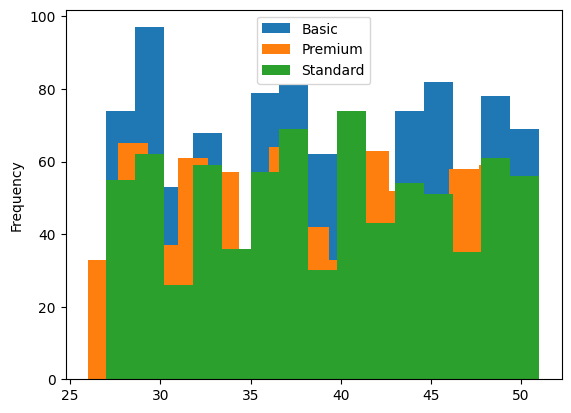

In [231]:
netflix.groupby("Subscription Type")["Age"].plot.hist(legend=True, bins=15)

In [149]:
netflix

,User ID,Subscription Type,Monthly Revenue,Join Date,Last Payment Date,Country,Age,Gender,Device,Plan Duration
0,1,Basic,10,15-01-22,10-06-23,United States,28,Male,Smartphone,1 Month
1,2,Premium,15,05-09-21,22-06-23,Canada,35,Female,Tablet,1 Month
2,3,Standard,12,28-02-23,27-06-23,United Kingdom,42,Male,Smart TV,1 Month
3,4,Standard,12,10-07-22,26-06-23,Australia,51,Female,Laptop,1 Month
4,5,Basic,10,01-05-23,28-06-23,Germany,33,Male,Smartphone,1 Month
...,...,...,...,...,...,...,...,...,...,...
2495,2496,Premium,14,25-07-22,12-07-23,Spain,28,Female,Smart TV,1 Month
2496,2497,Basic,15,04-08-22,14-07-23,Spain,33,Female,Smart TV,1 Month
2497,2498,Standard,12,09-08-22,15-07-23,United States,38,Male,Laptop,1 Month
2498,2499,Standard,13,12-08-22,12-07-23,Canada,48,Female,Tablet,1 Month


In [211]:
# 6)Is there a significant gender preference for certain subscription types or devices?

device = netflix.groupby(["Gender", "Device"]).size().reset_index()
device.rename(columns = {0 :"count"}, inplace = True)
device

,Gender,Device,count
0,Female,Laptop,329
1,Female,Smart TV,305
2,Female,Smartphone,300
3,Female,Tablet,323
4,Male,Laptop,307
5,Male,Smart TV,305
6,Male,Smartphone,321
7,Male,Tablet,310


In [212]:
device.sort_values(by = "count", ascending = False).drop_duplicates(subset = "Gender")

,Gender,Device,count
0,Female,Laptop,329
6,Male,Smartphone,321


In [213]:
subs = netflix.groupby(["Gender", "Subscription Type"]).size().reset_index()
subs.rename(columns = {0 :"count"}, inplace = True)
subs

,Gender,Subscription Type,count
0,Female,Basic,512
1,Female,Premium,364
2,Female,Standard,381
3,Male,Basic,487
4,Male,Premium,369
5,Male,Standard,387


In [214]:
subs.sort_values(by = "count", ascending = False).drop_duplicates(subset = "Gender")

,Gender,Subscription Type,count
0,Female,Basic,512
3,Male,Basic,487


In [215]:
temp = netflix.groupby(["Gender", "Subscription Type", "Device"]).size().reset_index()
temp.rename(columns = {0 :"count"}, inplace = True)

In [216]:
temp.sort_values(by = "count", ascending = False).drop_duplicates(subset = "Gender")

,Gender,Subscription Type,Device,count
0,Female,Basic,Laptop,136
14,Male,Basic,Smartphone,127


In [217]:
# 7)Which device type contributes the highest total revenue globally?
netflix.groupby("Device")["Monthly Revenue"].sum().idxmax()

'Laptop'

In [218]:
# 8)Is there a correlation between device used and age group?

In [219]:
# creating age gro col:
def age_grp(x):
    if x<20:
        return "less than 20"
    elif x<30 and x>=20:
        return "20-29"
    elif x>=30 and x<40:
        return "30-39"
    elif x>=40 and x<50:
        return "40-49"
    elif x>=50 and x<60:
        return "50-59"
    else:
        return "greater than 60"

In [220]:
netflix["Age group"] = netflix["Age"].apply(age_grp )

In [221]:
netflix

,User ID,Subscription Type,Monthly Revenue,Join Date,Last Payment Date,Country,Age,Gender,Device,Plan Duration,Age group
0,1,Basic,10,15-01-22,10-06-23,United States,28,Male,Smartphone,1 Month,20-29
1,2,Premium,15,05-09-21,22-06-23,Canada,35,Female,Tablet,1 Month,30-39
2,3,Standard,12,28-02-23,27-06-23,United Kingdom,42,Male,Smart TV,1 Month,40-49
3,4,Standard,12,10-07-22,26-06-23,Australia,51,Female,Laptop,1 Month,50-59
4,5,Basic,10,01-05-23,28-06-23,Germany,33,Male,Smartphone,1 Month,30-39
...,...,...,...,...,...,...,...,...,...,...,...
2495,2496,Premium,14,25-07-22,12-07-23,Spain,28,Female,Smart TV,1 Month,20-29
2496,2497,Basic,15,04-08-22,14-07-23,Spain,33,Female,Smart TV,1 Month,30-39
2497,2498,Standard,12,09-08-22,15-07-23,United States,38,Male,Laptop,1 Month,30-39
2498,2499,Standard,13,12-08-22,12-07-23,Canada,48,Female,Tablet,1 Month,40-49


In [222]:
device = netflix.groupby(["Age group", "Device"]).size().reset_index()
device.rename(columns = {0 :"count"}, inplace = True)

In [223]:
device.sort_values(by = "count", ascending = False).drop_duplicates(subset = "Age group")

,Age group,Device,count
8,40-49,Laptop,264
5,30-39,Smart TV,259
3,20-29,Tablet,81
12,50-59,Laptop,48


In [232]:
# 9)Which top 3 countries generate the most monthly revenue, and how is it split by subscription type?
netflix

,User ID,Subscription Type,Monthly Revenue,Join Date,Last Payment Date,Country,Age,Gender,Device,Plan Duration,Age group
0,1,Basic,10,15-01-22,10-06-23,United States,28,Male,Smartphone,1 Month,20-29
1,2,Premium,15,05-09-21,22-06-23,Canada,35,Female,Tablet,1 Month,30-39
2,3,Standard,12,28-02-23,27-06-23,United Kingdom,42,Male,Smart TV,1 Month,40-49
3,4,Standard,12,10-07-22,26-06-23,Australia,51,Female,Laptop,1 Month,50-59
4,5,Basic,10,01-05-23,28-06-23,Germany,33,Male,Smartphone,1 Month,30-39
...,...,...,...,...,...,...,...,...,...,...,...
2495,2496,Premium,14,25-07-22,12-07-23,Spain,28,Female,Smart TV,1 Month,20-29
2496,2497,Basic,15,04-08-22,14-07-23,Spain,33,Female,Smart TV,1 Month,30-39
2497,2498,Standard,12,09-08-22,15-07-23,United States,38,Male,Laptop,1 Month,30-39
2498,2499,Standard,13,12-08-22,12-07-23,Canada,48,Female,Tablet,1 Month,40-49


In [280]:
country_rev = netflix.groupby("Country")["Monthly Revenue"].sum().reset_index()
country_rev

,Country,Monthly Revenue
0,Australia,2271
1,Brazil,2285
2,Canada,3950
3,France,2307
4,Germany,2260
5,Italy,2317
6,Mexico,2237
7,Spain,5662
8,United Kingdom,2318
9,United States,5664


In [282]:
top3 = country_rev.sort_values(by="Monthly Revenue", ascending=False).head(3)
top3

,Country,Monthly Revenue
9,United States,5664
7,Spain,5662
2,Canada,3950


In [283]:
subs_top3 = subs[subs["Country"].isin(top3["Country"])]
subs_top3

,Country,Subscription Type,Monthly Revenue
0,Canada,Basic,1816
1,Canada,Premium,1086
2,Canada,Standard,1048
3,Spain,Basic,1386
4,Spain,Premium,2689
5,Spain,Standard,1587
6,United States,Basic,2483
7,United States,Premium,1837
8,United States,Standard,1344


In [285]:
split = subs_top3.pivot(index="Country", columns="Subscription Type", values="Monthly Revenue").fillna(0)
split["Total"] = split.sum(axis=1)
split


Subscription Type,Basic,Premium,Standard,Total
Country,,,,
Canada,1816,1086,1048,3950
Spain,1386,2689,1587,5662
United States,2483,1837,1344,5664


In [295]:
# 10)Does device preference vary significantly across regions?

device = netflix.groupby(["Country", "Device"]).size().reset_index()
device.rename(columns = {0 :"count"}, inplace = True)
device

,Country,Device,count
0,Australia,Laptop,47
1,Australia,Smart TV,38
2,Australia,Smartphone,55
3,Australia,Tablet,43
4,Brazil,Laptop,44
5,Brazil,Smart TV,40
6,Brazil,Smartphone,55
7,Brazil,Tablet,44
8,Canada,Laptop,64
9,Canada,Smart TV,78


In [297]:
c_device = device.sort_values(by = "count", ascending = False).drop_duplicates(subset = "Country")
c_device

,Country,Device,count
29,Spain,Smart TV,126
36,United States,Laptop,121
11,Canada,Tablet,95
16,Germany,Laptop,63
2,Australia,Smartphone,55
6,Brazil,Smartphone,55
34,United Kingdom,Smartphone,54
27,Mexico,Tablet,52
12,France,Laptop,52
20,Italy,Laptop,50


In [299]:
preference = device.pivot_table(index = "Country", columns = "Device", values = "count", margins = True)
preference

Device,Laptop,Smart TV,Smartphone,Tablet,All
Country,,,,,
Australia,47.0,38.0,55.0,43.0,45.75
Brazil,44.0,40.0,55.0,44.0,45.75
Canada,64.0,78.0,80.0,95.0,79.25
France,52.0,43.0,47.0,41.0,45.75
Germany,63.0,42.0,36.0,42.0,45.75
Italy,50.0,46.0,47.0,40.0,45.75
Mexico,44.0,41.0,46.0,52.0,45.75
Spain,107.0,126.0,102.0,116.0,112.75
United Kingdom,44.0,40.0,54.0,45.0,45.75


In [335]:
#25)Based on device usage, can we predict the preferred subscription type (e.g., do Smart TV users lean more towards Premium)?

temp = netflix.groupby(["Device","Subscription Type"]).size().reset_index()
temp.rename(columns = {0 :"count"}, inplace = True)
temp


,Device,Subscription Type,count
0,Laptop,Basic,259
1,Laptop,Premium,192
2,Laptop,Standard,185
3,Smart TV,Basic,238
4,Smart TV,Premium,188
5,Smart TV,Standard,184
6,Smartphone,Basic,251
7,Smartphone,Premium,171
8,Smartphone,Standard,199
9,Tablet,Basic,251


In [336]:
temp.sort_values(by = "count", ascending = False).drop_duplicates(subset = "Device")

,Device,Subscription Type,count
0,Laptop,Basic,259
6,Smartphone,Basic,251
9,Tablet,Basic,251
3,Smart TV,Basic,238


##### all device users prefer basic subcription typee

In [346]:
#26)Can we detect if older users (above 40) are more likely to use Laptops/Tablets, while younger users (below 30) prefer Smartphones/Smart TVs?
device = netflix[netflix["Age group"].isin(["40-49",""])].groupby(["Age group", "Device"]).size().reset_index()
device.rename(columns = {0 :"count"}, inplace = True)
device

In [347]:
device.sort_values(by = "count", ascending = False).drop_duplicates(subset = "Age group")

,Age group,Device,count
8,40-49,Laptop,264
5,30-39,Smart TV,259
3,20-29,Tablet,81
12,50-59,Laptop,48


In [348]:
old = netflix[netflix["Age group"].isin(["40-49", "50-59", "above 60"])]

In [352]:
young = netflix[netflix["Age group"].isin(["20-29", "less than 20"])]


In [360]:
old.groupby("Device").size().idxmax() # commonly used device among old age people

'Laptop'

In [361]:
young.groupby("Device").size().idxmax() # commonly used device among old young people

'Tablet'

In [362]:
## 22)On average, how many months do users remain subscribed before their last payment? Does this vary by subscription type?
netflix.sample()

,User ID,Subscription Type,Monthly Revenue,Join Date,Last Payment Date,Country,Age,Gender,Device,Plan Duration,Age group,lifetime_days,lifetime_months
1789,1790,Basic,12,2022-06-30,2023-09-07,Italy,31,Male,Smart TV,1 Month,30-39,434,14.47


In [364]:
# average months do users remain subscribed before their last payment
netflix["lifetime_months"].mean().item()

10.869984

In [377]:
#Does this vary by subscription type?   no it doesn't vary
netflix.groupby("Subscription Type")["lifetime_months"].mean().reset_index()

,Subscription Type,lifetime_months
0,Basic,10.880941
1,Premium,10.776262
2,Standard,10.945182


In [372]:
# 21)What is the average monthly revenue trend across join dates (e.g., users who joined in 2021 vs 2022 vs 2023)?
netflix["joining year"] = netflix["Join Date"].dt.year

In [376]:
netflix.groupby("joining year")["Monthly Revenue"].mean().reset_index()

,joining year,Monthly Revenue
0,2021,12.571429
1,2022,12.514297
2,2023,12.105263


In [375]:
# 17)How much total revenue has been generated from each device type (Smartphone, Laptop, Tablet, Smart TV)?
netflix.groupby("Device")["Monthly Revenue"].sum().reset_index()

,Device,Monthly Revenue
0,Laptop,7994
1,Smart TV,7615
2,Smartphone,7691
3,Tablet,7971


In [379]:
# 19)Is there a significant gender difference in subscription preference (Basic, Standard, Premium)?
subs = netflix.groupby(["Gender", "Subscription Type"]).size().reset_index()
subs.rename(columns = {0 :"count"}, inplace = True)
subs

,Gender,Subscription Type,count
0,Female,Basic,512
1,Female,Premium,364
2,Female,Standard,381
3,Male,Basic,487
4,Male,Premium,369
5,Male,Standard,387


In [381]:
subs.sort_values(by = "count", ascending = False).drop_duplicates(subset = "Gender")

,Gender,Subscription Type,count
0,Female,Basic,512
3,Male,Basic,487


In [385]:
# 18)Which age group spends the most on subscriptions?
netflix.groupby("Age group")["Monthly Revenue"].sum().reset_index().sort_values(by = "Monthly Revenue").tail(1)

,Age group,Monthly Revenue
1,30-39,12747


In [386]:
# 15)What is the average subscription length (difference between join date and last payment date) across different subscription types?

netflix.groupby("Subscription Type")["lifetime_months"].mean().reset_index()

,Subscription Type,lifetime_months
0,Basic,10.880941
1,Premium,10.776262
2,Standard,10.945182


In [397]:
# 16)Which country has the highest churn rate (users with the shortest subscription duration)?
netflix[netflix["lifetime_months"]==netflix["lifetime_months"].min()]["Country"].values.item()

'Italy'

In [400]:
# 20)Which country has the highest proportion of Premium subscribers compared to Basic and Standard?
# subs = netflix.groupby(["Country", "Subscription Type"]).size().reset_index()
# subs.rename(columns = {0 :"count"}, inplace = True)
# subs

#### Q-5)Below questions are based on this data(Salaries):-
1)Which job titles rely most heavily on OvertimePay compared to BasePay?

2)What is the proportion of Benefits to TotalPay across different departments/roles?

3)Are there any employees where OtherPay exceeds BasePay, and why?

4)Who are the top 10 highest-paid employees, and what proportion of their pay is overtime?

5)Are there job titles where average BasePay is low, but TotalPay is high due to overtime or other pay?

6)Identify outliers where Benefits or OvertimePay are disproportionately high compared to peers.

7)Which job titles have the highest median TotalPay?

8)Compare executive roles (e.g., Department Heads) vs operational roles (e.g., Firefighters, Police) in terms of TotalPay distribution.

9)Does seniority in job title (e.g., Chief vs Assistant) consistently correlate with higher TotalPay?

10)How does TotalPayBenefits vary across years (if multiple years exist)?


In [403]:
salary = pd.read_csv("Salaries.csv")
salary.sample(5)

C:\Users\Hp\AppData\Local\Temp\ipykernel_21512\3446048390.py:1: DtypeWarning: Columns (3,4,5,6,12) have mixed types. Specify dtype option on import or set low_memory=False.
  salary = pd.read_csv("Salaries.csv")


,Id,EmployeeName,JobTitle,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year,Notes,Agency,Status
28159,28160,MARIA CORAZO MUNSAYAC,SPECIAL NURSE,23918.23,0.0,4718.93,NaN,28637.16,28637.16,2011,NaN,San Francisco,NaN
83838,83839,Gregg P Snell,Stationary Engineer,78470.6,18881.22,6525.12,30414.82,103876.94,134291.76,2013,NaN,San Francisco,NaN
57183,57184,R V Gaerlan,Senior Legal Process Clerk,55909.76,6661.66,0.0,28843.53,62571.42,91414.95,2012,NaN,San Francisco,NaN
134883,134884,Helen A Lee,Clerk Typist,54443.00,0.00,624.00,26791.35,55067.00,81858.35,2014,NaN,San Francisco,FT
121486,121487,David H Tong,Asst Engr,97333.07,0.0,1625.22,35500.02,98958.29,134458.31,2014,NaN,San Francisco,FT


In [414]:
salary["OvertimePay"] = pd.to_numeric(salary["OvertimePay"], errors = "coerce", downcast = "float")

In [415]:
salary["OvertimePay"].dtype

dtype('float64')

In [429]:
salary["Benefits"] = pd.to_numeric(salary["Benefits"], errors = "coerce", downcast = "float")

In [430]:
salary["Benefits"].dtype

dtype('float64')

In [479]:
salary["BasePay"] = pd.to_numeric(salary["BasePay"], errors = "coerce", downcast = "float")

In [480]:
salary["TotalPay"].dtype

dtype('float64')

In [425]:
# 1)Which job titles rely most heavily on OvertimePay compared to BasePay?


In [428]:
salary[salary["OvertimePay"]>0.00].groupby("JobTitle")["OvertimePay"].sum().reset_index().sort_values(by = "OvertimePay", ascending = False).head(5)

,JobTitle,OvertimePay
1145,Transit Operator,78403983.45
414,Firefighter,66931108.48
804,Police Officer 3,39748129.59
302,Deputy Sheriff,27702498.14
1108,TRANSIT OPERATOR,27082442.42


In [446]:
#2)What is the proportion of Benefits to TotalPay across different departments/roles?
temp = salary.groupby("JobTitle")[["Benefits","TotalPay"]].sum().reset_index()
temp["Benefits to TotalPay"] =round( (temp["Benefits"]/temp["TotalPay"])*100,2)
temp

,JobTitle,Benefits,TotalPay,Benefits to TotalPay
0,ACCOUNT CLERK,0.00,3654960.14,0.00
1,ACCOUNTANT,0.00,237146.34,0.00
2,ACCOUNTANT INTERN,0.00,1393523.66,0.00
3,"ACPO,JuvP, Juv Prob (SFERS)",17975.59,62290.78,28.86
4,ACUPUNCTURIST,0.00,67594.40,0.00
...,...,...,...,...
2154,X-RAY LABORATORY AIDE,0.00,1370352.89,0.00
2155,X-Ray Laboratory Aide,1869718.05,5082394.27,36.79
2156,"YOUTH COMMISSION ADVISOR, BOARD OF SUPERVISORS",0.00,53632.87,0.00
2157,Youth Comm Advisor,74816.97,165657.23,45.16


In [447]:
# 3)Are there any employees where OtherPay exceeds BasePay, and why?
salary.sample()

,Id,EmployeeName,JobTitle,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year,Notes,Agency,Status
85316,85317,David M Nakanishi,Sr Psychiatric Social Worker,94851.04,0.0,0.0,32530.74,94851.04,127381.78,2013,NaN,San Francisco,NaN


In [458]:
temp =salary[salary["OtherPay"] > salary["BasePay"]][["EmployeeName","Agency"]] 
## all who works in  san francisco has higher other pay than base pay
temp

,EmployeeName,Agency
0,NATHANIEL FORD,San Francisco
3,CHRISTOPHER CHONG,San Francisco
4,PATRICK GARDNER,San Francisco
5,DAVID SULLIVAN,San Francisco
6,ALSON LEE,San Francisco
...,...,...
148621,Kenneth Mackey,San Francisco
148622,Jacqueline Hubbard,San Francisco
148623,Deborah B Honig,San Francisco
148624,Lorraine Rosenthal,San Francisco


In [462]:
#4)Who are the top 10 highest-paid employees, and what proportion of their pay is overtime?
highest_pays = salary["TotalPay"].sort_values(ascending = False).head(10).values
highest_pays

array([567595.43, 538909.28, 471952.64, 390111.98, 362844.66, 350403.41,
       347102.32, 344187.46, 339653.7 , 339282.07])

In [467]:
temp = salary[salary["TotalPay"].isin(highest_pays)]

In [476]:
temp["overtime to pay percent"] = round((temp["OvertimePay"]/temp["TotalPay"])*100,2)

C:\Users\Hp\AppData\Local\Temp\ipykernel_21512\1698609109.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp["overtime to pay percent"] = round((temp["OvertimePay"]/temp["TotalPay"])*100,2)


In [477]:
temp

,Id,EmployeeName,JobTitle,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year,Notes,Agency,Status,overtime to pay,overtime to pay percent
0,1,NATHANIEL FORD,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,167411.18,0.00,400184.25,NaN,567595.43,567595.43,2011,NaN,San Francisco,NaN,0.00,0.00
1,2,GARY JIMENEZ,CAPTAIN III (POLICE DEPARTMENT),155966.02,245131.88,137811.38,NaN,538909.28,538909.28,2011,NaN,San Francisco,NaN,45.49,45.49
36159,36160,Gary Altenberg,"Lieutenant, Fire Suppression",128808.87,220909.48,13126.31,44430.12,362844.66,407274.78,2012,NaN,San Francisco,NaN,60.88,60.88
36167,36168,John Goldberg,Captain 3,104404.0,0.00,245999.41,24287.23,350403.41,374690.64,2012,NaN,San Francisco,NaN,0.00,0.00
72925,72926,Gregory P Suhr,Chief of Police,319275.01,0.00,20007.06,86533.21,339282.07,425815.28,2013,NaN,San Francisco,NaN,0.00,0.00
72927,72928,Samson Lai,"Battalion Chief, Fire Suppress",186236.42,131217.63,29648.27,57064.95,347102.32,404167.27,2013,NaN,San Francisco,NaN,37.80,37.80
110531,110532,David Shinn,Deputy Chief 3,129150.01,0.00,342802.63,38780.04,471952.64,510732.68,2014,NaN,San Francisco,PT,0.00,0.00
110532,110533,Amy P Hart,Asst Med Examiner,318835.49,10712.95,60563.54,89540.23,390111.98,479652.21,2014,NaN,San Francisco,FT,2.75,2.75
110533,110534,William J Coaker Jr.,Chief Investment Officer,257340.0,0.00,82313.7,96570.66,339653.70,436224.36,2014,NaN,San Francisco,PT,0.00,0.00
110536,110537,Ellen G Moffatt,Asst Med Examiner,270222.04,6009.22,67956.2,71580.48,344187.46,415767.94,2014,NaN,San Francisco,FT,1.75,1.75


In [483]:
#5)Are there job titles where average BasePay is low, but TotalPay is high due to overtime or other pay?
avg_basepay = salary["BasePay"].mean().item()
avg_basepay

66325.4488404877

In [492]:
np.unique(salary[(salary["BasePay"]<avg_basepay) & (salary["TotalPay"]>salary["BasePay"])]["JobTitle"].values)

array(['ACCOUNT CLERK', 'ACCOUNTANT', 'ACCOUNTANT INTERN', ...,
       'YOUTH COMMISSION ADVISOR, BOARD OF SUPERVISORS',
       'Youth Comm Advisor', 'ZOO CURATOR'], dtype=object)

In [495]:
#7)Which job titles have the highest median TotalPay?
salary.groupby("JobTitle").agg({"TotalPay" : "median"}).reset_index().sort_values(by = "TotalPay").tail()

,JobTitle,TotalPay
586,DEPUTY DIRECTOR OF INVESTMENTS,307899.460
475,"Chief, Fire Department",326233.440
474,Chief of Police,326716.760
466,Chief Investment Officer,339653.700
831,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,399211.275


In [500]:
#8)Compare executive roles (e.g., Department Heads) vs operational roles (e.g., Firefighters, Police) in terms of TotalPay distribution.
#salary["JobTitle"].value_counts().unique

In [501]:
#10)How does TotalPayBenefits vary across years (if multiple years exist)?
salary.sample()

,Id,EmployeeName,JobTitle,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year,Notes,Agency,Status
76652,76653,Stephon C Degand,Police Officer 2,115670.28,27861.43,8049.88,37073.67,151581.59,188655.26,2013,NaN,San Francisco,NaN


In [505]:
salary.groupby("Year")["TotalPayBenefits"].sum().reset_index()

,Year,TotalPayBenefits
0,2011,2.594195e+09
1,2012,3.696940e+09
2,2013,3.814772e+09
3,2014,3.821866e+09


In [523]:
#12)Calculate the pay gap ratio between the highest-paid and lowest-paid employees.
highest_pay = salary["TotalPay"].sort_values(ascending = False).head(10).reset_index(drop = True)
#highest_pay = highest_pay.item()
highest_pay

0    567595.43
1    538909.28
2    471952.64
3    390111.98
4    362844.66
5    350403.41
6    347102.32
7    344187.46
8    339653.70
9    339282.07
Name: TotalPay, dtype: float64

In [521]:
lowest_pay = salary["TotalPay"].sort_values().head(10).reset_index(drop = True)
# lowest_pay = lowest_pay.item()
lowest_pay 

0   -618.13
1      0.00
2      0.00
3      0.00
4      0.00
5      0.00
6      0.00
7      0.00
8      0.00
9      0.00
Name: TotalPay, dtype: float64

In [526]:
highest_pay/lowest_pay

0   -918.246049
1           inf
2           inf
3           inf
4           inf
5           inf
6           inf
7           inf
8           inf
9           inf
Name: TotalPay, dtype: float64

In [552]:
# 13)Within the same job title, what is the pay variance (difference between max and min pay)?
temp = salary.groupby("JobTitle").agg({"TotalPay":["min", "max"]}).reset_index()
temp["pay variance"] = temp["TotalPay"]["max"] - temp["TotalPay"]["min"]
temp

JobTitle  TotalPay            \
                                                           min       max   
0                                      ACCOUNT CLERK    614.00  60838.20   
1                                         ACCOUNTANT   1148.40  65392.01   
2                                  ACCOUNTANT INTERN   2981.53  58799.53   
3                        ACPO,JuvP, Juv Prob (SFERS)  62290.78  62290.78   
4                                      ACUPUNCTURIST  67594.40  67594.40   
...                                              ...       ...       ...   
2154                           X-RAY LABORATORY AIDE   5343.69  85077.40   
2155                           X-Ray Laboratory Aide   1007.00  99812.97   
2156  YOUTH COMMISSION ADVISOR, BOARD OF SUPERVISORS  53632.87  53632.87   
2157                              Youth Comm Advisor  19212.71  57544.73   
2158                                     ZOO CURATOR  66686.56  66686.56   

     pay variance  
                   
0        60224.20  
1        64243.61  
2        55818.00  
3            0.00  
4            0.00  
...           ...  
2154     79733.71  
2155     98805.97  
2156         0.00  
2157     38332.02  
2158         0.00  

[2159 rows x 4 columns]

In [553]:
#14)Which job titles show the largest internal salary disparity?
temp.sort_values(by = "pay variance").tail()

JobTitle   TotalPay             \
                                                            min        max   
831   GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY  230827.12  567595.43   
698                        EMT/Paramedic/Firefighter       0.00  337204.86   
1083                    Lieutenant, Fire Suppression   11646.58  362844.66   
218                                Asst Med Examiner   38840.00  390111.98   
293                  CAPTAIN III (POLICE DEPARTMENT)   91929.37  538909.28   

     pay variance  
                   
831     336768.31  
698     337204.86  
1083    351198.08  
218     351271.98  
293     446979.91

In [527]:
#19)What percentage of employees would fall below $100,000 TotalPay if Benefits were excluded?
salary

,Id,EmployeeName,JobTitle,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year,Notes,Agency,Status
0,1,NATHANIEL FORD,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,167411.18,0.00,400184.25,NaN,567595.43,567595.43,2011,NaN,San Francisco,NaN
1,2,GARY JIMENEZ,CAPTAIN III (POLICE DEPARTMENT),155966.02,245131.88,137811.38,NaN,538909.28,538909.28,2011,NaN,San Francisco,NaN
2,3,ALBERT PARDINI,CAPTAIN III (POLICE DEPARTMENT),212739.13,106088.18,16452.6,NaN,335279.91,335279.91,2011,NaN,San Francisco,NaN
3,4,CHRISTOPHER CHONG,WIRE ROPE CABLE MAINTENANCE MECHANIC,77916.00,56120.71,198306.9,NaN,332343.61,332343.61,2011,NaN,San Francisco,NaN
4,5,PATRICK GARDNER,"DEPUTY CHIEF OF DEPARTMENT,(FIRE DEPARTMENT)",134401.60,9737.00,182234.59,NaN,326373.19,326373.19,2011,NaN,San Francisco,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
148649,148650,Roy I Tillery,Custodian,0.00,0.00,0.00,0.0,0.00,0.00,2014,NaN,San Francisco,PT
148650,148651,Not provided,Not provided,NaN,NaN,Not Provided,NaN,0.00,0.00,2014,NaN,San Francisco,NaN
148651,148652,Not provided,Not provided,NaN,NaN,Not Provided,NaN,0.00,0.00,2014,NaN,San Francisco,NaN
148652,148653,Not provided,Not provided,NaN,NaN,Not Provided,NaN,0.00,0.00,2014,NaN,San Francisco,NaN


In [528]:
salary["Benefits"] = salary["Benefits"].fillna(0)

In [529]:
salary["TotalPay"] = salary["TotalPay"].fillna(0)

In [530]:
salary["total-benefits"] = salary["TotalPay"] - salary["Benefits"]

In [533]:
salary[salary["total-benefits"]<100000.00]["Id"].nunique()

126130

In [546]:
temp = salary.groupby("JobTitle").agg({"TotalPay":["min", "max"]}).reset_index()
temp.sort

JobTitle  TotalPay          
                                                           min       max
0                                      ACCOUNT CLERK    614.00  60838.20
1                                         ACCOUNTANT   1148.40  65392.01
2                                  ACCOUNTANT INTERN   2981.53  58799.53
3                        ACPO,JuvP, Juv Prob (SFERS)  62290.78  62290.78
4                                      ACUPUNCTURIST  67594.40  67594.40
...                                              ...       ...       ...
2154                           X-RAY LABORATORY AIDE   5343.69  85077.40
2155                           X-Ray Laboratory Aide   1007.00  99812.97
2156  YOUTH COMMISSION ADVISOR, BOARD OF SUPERVISORS  53632.87  53632.87
2157                              Youth Comm Advisor  19212.71  57544.73
2158                                     ZOO CURATOR  66686.56  66686.56

[2159 rows x 3 columns]

In [547]:
temp["TotalPay"]["min"]

0         614.00
1        1148.40
2        2981.53
3       62290.78
4       67594.40
          ...   
2154     5343.69
2155     1007.00
2156    53632.87
2157    19212.71
2158    66686.56
Name: min, Length: 2159, dtype: float64

In [554]:
# 15)Which departments are most dependent on overtime to boost salaries?
salary[salary["OvertimePay"]>0.00].groupby("JobTitle")["OvertimePay"].sum().reset_index().sort_values(by = "OvertimePay", ascending = False).head(5)

,JobTitle,OvertimePay
1145,Transit Operator,78403983.45
414,Firefighter,66931108.48
804,Police Officer 3,39748129.59
302,Deputy Sheriff,27702498.14
1108,TRANSIT OPERATOR,27082442.42


#### Q-4)Below questions are based on this data(Loan_default):-
1)How does Credit Score distribution differ between defaulted vs non-defaulted loans?

2)What is the probability of default for each Loan Purpose (Auto, Business, Home, Education, Other)?

3)Is there a threshold of DTI Ratio (Debt-to-Income) above which defaults significantly increase?

4)Does Marital Status or Employment Type significantly impact default rates?

5)Which Education level borrowers are most likely to default, after adjusting for Income and Loan Amount?

6)Are younger vs older borrowers (using proxy = MonthsEmployed) at higher risk?

7)For borrowers with similar Income levels, does LoanAmount size affect default likelihood?

8)Is there a relationship between NumCreditLines and Loan Default Rate? (i.e., does having more credit lines reduce/increase risk?)

9)Does having a co-signer lower the probability of default?

10)Are borrowers with an existing mortgage more or less likely to default?


In [556]:
loan = pd.read_csv("Loan_default.csv")
loan.sample(5)

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
99507,UYHG9X5010,59,67318,200530,479,84,1,23.09,24,0.40,Bachelor's,Part-time,Divorced,Yes,Yes,Auto,Yes,0
221373,0Y2Q1ND63N,19,120757,243932,316,99,2,24.92,12,0.27,Bachelor's,Part-time,Married,No,Yes,Other,Yes,0
78542,5T3ROFA5J2,18,36955,9507,809,103,2,8.32,12,0.56,Master's,Part-time,Divorced,No,No,Business,Yes,0
207240,V8FFBAX3FV,44,132130,111556,372,24,3,23.45,60,0.38,High School,Self-employed,Single,Yes,No,Education,Yes,0
103924,0WRBEDFVVH,21,68487,192490,771,48,4,24.28,60,0.85,Master's,Unemployed,Married,Yes,No,Business,Yes,0


In [558]:
#1)How does Credit Score distribution differ between defaulted vs non-defaulted loans?
loan.groupby("Default").agg({"CreditScore":"mean"})

,CreditScore
Default,
0,576.232270
1,559.286143


In [561]:
#2)What is the probability of default for each Loan Purpose (Auto, Business, Home, Education, Other)?
temp = loan[loan["Default"]==1]
temp.groupby("LoanPurpose").size()

LoanPurpose
Auto         6041
Business     6323
Education    6038
Home         5249
Other        6002
dtype: int64